In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import re

In [3]:
path = r"../../DataPreprocessing/outputs/cleaned_courses_final.pkl"

In [4]:
df = pd.read_pickle(path)

In [5]:
df.head()

,ipeds_id,cat_type,start_yr,end_yr,page_num,col_num,type,annote_id,Department,Number,...,Prerequisites,Credits,Teacher,decade,quinquennium,DepartmentCleaned,id_course,id_dep_code,id_department_course,id_catalog
3180467,166638,ug,1999,2000,176,0,courses,757270,cmps,1999,...,nan,nan,nan,1990,1995,cmps,1999_Seeclel Topics,cmps_1999,cmps_Seeclel Topics,166638_ug_1999_2000
2622698,200280,gr,1960,1961,47,0,courses,804714,art,506,...,nan,nan,nan,1960,1960,art,506_Artist'S Techniques,art_506,art_Artist'S Techniques,200280_gr_1960_1961
3316808,200280,both,2001,2003,145,0,courses,742474,nutr,241,...,nan,nan,nan,2000,2000,nutr,241_Maternal And Child Nutrition,nutr_241,nutr_Maternal And Child Nutrition,200280_both_2001_2003
2640922,200280,ug,1964,1966,363,0,courses,806302,social work,447,...,nan,nan,nan,1960,1960,social work,447_Field Practice,social work_447,social work_Field Practice,200280_ug_1964_1966
2468269,166638,ug,1974,1975,160,2,courses,765273,edel,311,...,nan,nan,nan,1970,1970,edel,311_The Child And The Curriculum,edel_311,edel_The Child And The Curriculum,166638_ug_1974_1975


# Data Description

In [6]:
# what corresponds to each row
print("each row corresponds to a course catalog")

each row corresponds to a course catalog


In [8]:
# nr universities
aux_ = df["ipeds_id"].value_counts()
print(f"The dataset has {aux_.shape[0]} universities\n")
aux_

The dataset has 25 universities



ipeds_id
204796    493698
110662    454905
166638    251854
110635    238311
199120    225318
126614    208563
233921    197171
231174    194252
163286    172424
134097    168137
232186    164172
190415    158360
200280    143117
129020    130224
187985    122069
156125    120953
243744     93744
211440     91205
102553     89275
100663     86412
142115     81427
199148     70127
147767     55259
100751     54275
228723     45580
Name: count, dtype: int64

In [9]:
###in the DB there is already a id_catalog. for this NLP project purpose we created it here
df["id_catalog"] = (
    df["ipeds_id"].astype(str)
    + "_"
    + df["cat_type"].astype(str)
    + "_"
    + df["start_yr"].astype(str)
    + "_"
    + df["end_yr"].astype(str)
)

In [10]:
# nr catalogs
aux_ = df["id_catalog"].value_counts()
print(f"The dataset has {aux_.shape[0]} catalogs\n")
aux_

The dataset has 1668 catalogs



id_catalog
204796_both_2015_2016    13197
204796_both_2014_2015    12966
110662_ug_2019_2020      12736
110662_ug_2020_2021      12677
204796_both_2016_2017    12574
                         ...  
166638_both_1892_1893        1
200280_both_1886_1887        1
200280_both_1900_1901        1
163286_both_1907_1908        1
200280_both_1887_1888        1
Name: count, Length: 1668, dtype: int64

In [11]:
# nr courses
aux_ = df.shape[0]
print(f"The dataset has {aux_} catalogs\n")
aux_

The dataset has 4110832 catalogs



4110832

In [12]:
# nr features that we have
aux_ = df.columns
print(f"The dataset has {len(aux_)} features\n")
aux_

The dataset has 22 features



Index(['ipeds_id', 'cat_type', 'start_yr', 'end_yr', 'page_num', 'col_num',
       'type', 'annote_id', 'Department', 'Number', 'Title', 'Description',
       'Prerequisites', 'Credits', 'Teacher', 'decade', 'quinquennium',
       'DepartmentCleaned', 'id_course', 'id_dep_code', 'id_department_course',
       'id_catalog'],
      dtype='object')

In [13]:
df.head()

,ipeds_id,cat_type,start_yr,end_yr,page_num,col_num,type,annote_id,Department,Number,...,Prerequisites,Credits,Teacher,decade,quinquennium,DepartmentCleaned,id_course,id_dep_code,id_department_course,id_catalog
3180467,166638,ug,1999,2000,176,0,courses,757270,cmps,1999,...,nan,nan,nan,1990,1995,cmps,1999_Seeclel Topics,cmps_1999,cmps_Seeclel Topics,166638_ug_1999_2000
2622698,200280,gr,1960,1961,47,0,courses,804714,art,506,...,nan,nan,nan,1960,1960,art,506_Artist'S Techniques,art_506,art_Artist'S Techniques,200280_gr_1960_1961
3316808,200280,both,2001,2003,145,0,courses,742474,nutr,241,...,nan,nan,nan,2000,2000,nutr,241_Maternal And Child Nutrition,nutr_241,nutr_Maternal And Child Nutrition,200280_both_2001_2003
2640922,200280,ug,1964,1966,363,0,courses,806302,social work,447,...,nan,nan,nan,1960,1960,social work,447_Field Practice,social work_447,social work_Field Practice,200280_ug_1964_1966
2468269,166638,ug,1974,1975,160,2,courses,765273,edel,311,...,nan,nan,nan,1970,1970,edel,311_The Child And The Curriculum,edel_311,edel_The Child And The Curriculum,166638_ug_1974_1975


In [ ]:
# distribution of courses per year per university per cat_type
aux_ = df.groupby(["ipeds_id", "cat_type", "start_yr"]).size()


In [15]:
df["cat_type"].value_counts()

cat_type
both    2471678
ug      1109539
gr       516139
voc       11821
misc       1090
law         565
Name: count, dtype: int64

In [16]:
# distribution of courses per year per university per cat_type

In [17]:
min_start_yr = df["start_yr"].min()
max_start_yr = df["start_yr"].max()

In [18]:
min_val = aux_.min().min()
max_val = aux_.max().max()

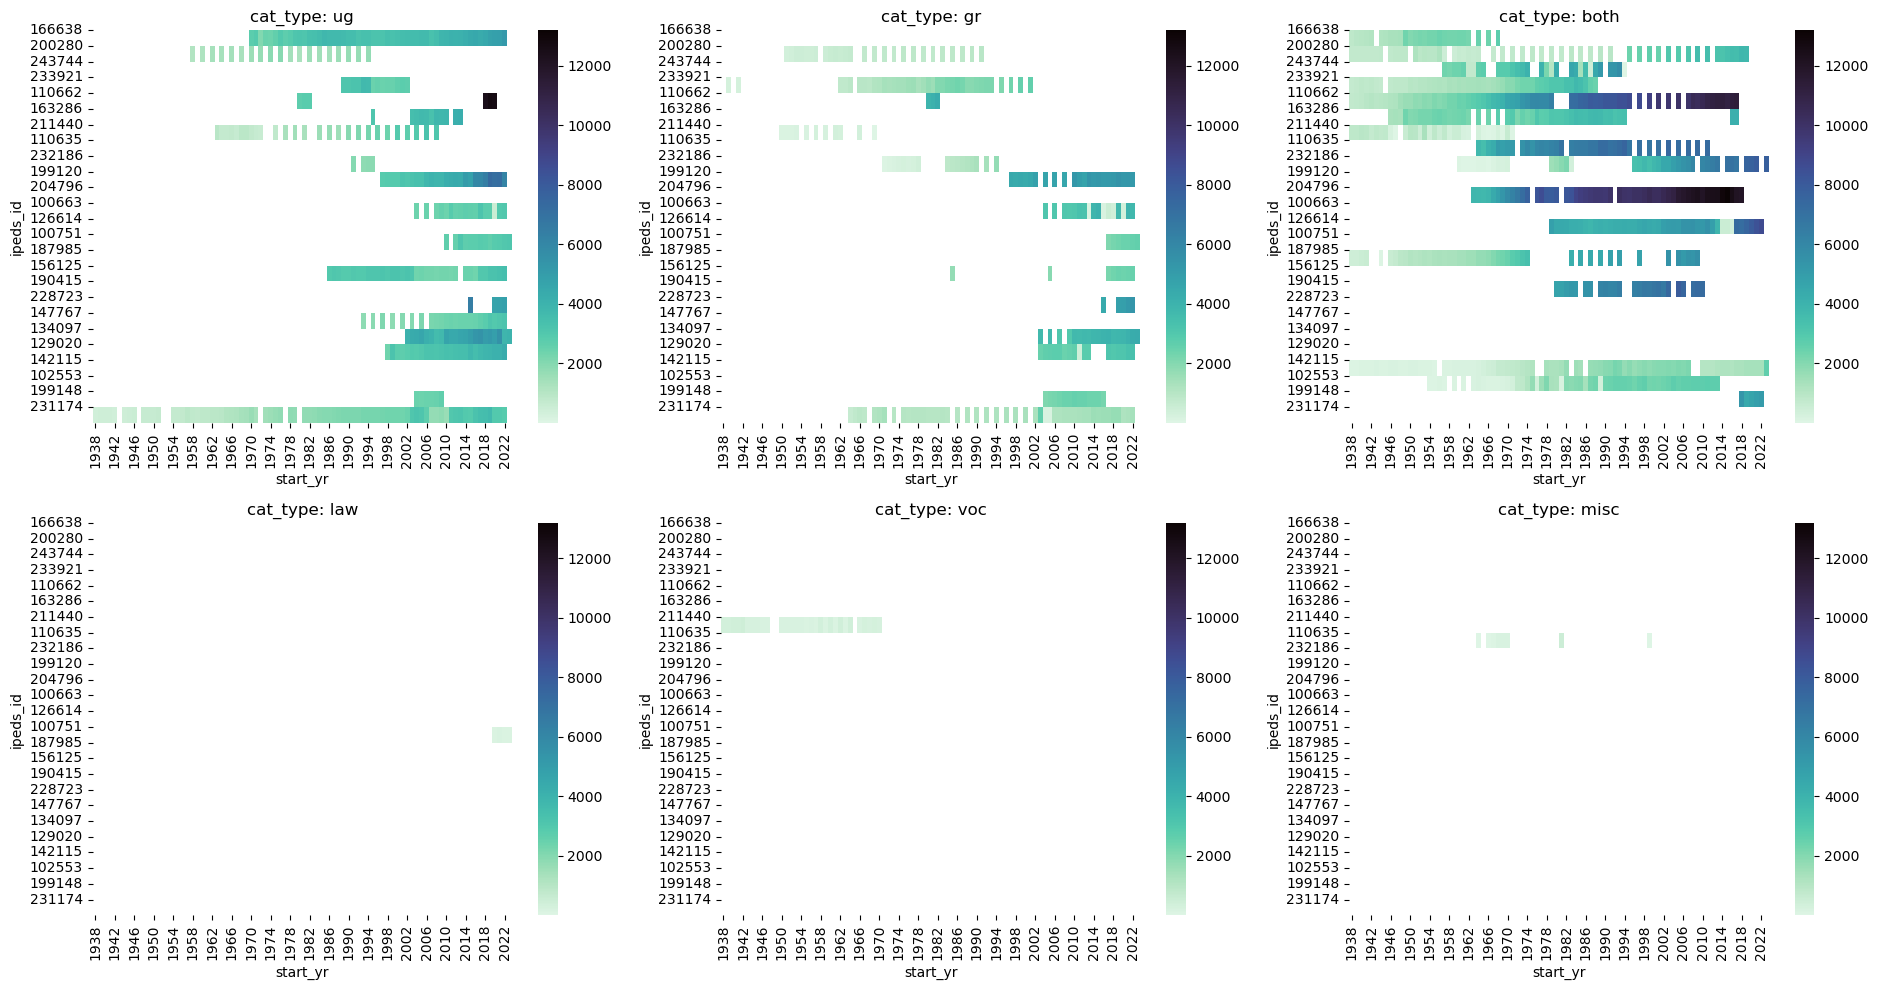

In [19]:
fig, axes_orig = plt.subplots(figsize=(19, 10), nrows=2, ncols=3)
axes = axes_orig.flatten()

full_index = df["ipeds_id"].unique()

##data to identify the number of courses per unique catalog
aux_ = df.groupby(["ipeds_id", "cat_type", "start_yr"]).size()

for idx, cat_type in enumerate(df["cat_type"].unique()):
    data_ = aux_.unstack().xs(cat_type, level="cat_type")

    sns.heatmap(
        # in AI_orig I tried to group words based on historical evolution of utilization. I tried to plot in same order to find visual clusters/patterns
        data_.reindex(columns=range(1938, 2024), fill_value=np.nan).reindex(
            index=full_index, fill_value=np.nan
        ),
        cmap=sns.color_palette("mako_r", as_cmap=True),
        vmax=max_val,
        vmin=min_val,
        ax=axes[idx],
    )
    axes[idx].set_title(f"cat_type: {cat_type}")
    axes[idx].set_yticks(range(len(full_index)))
    axes[idx].set_yticklabels(full_index)

plt.tight_layout()

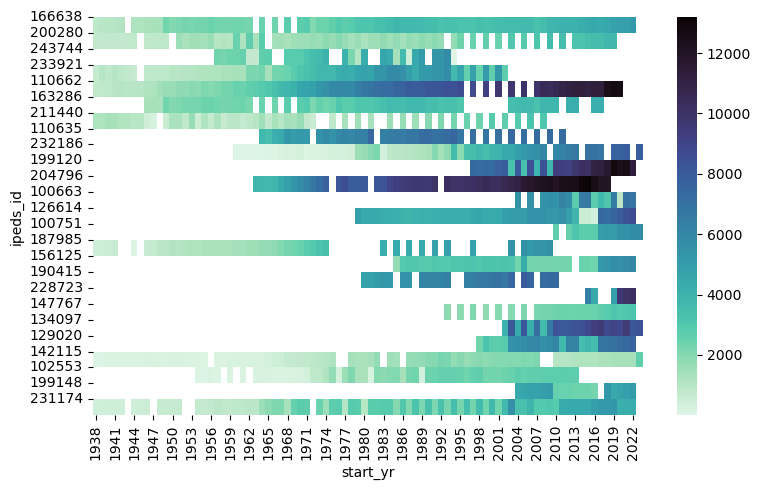

In [20]:
# distribution of courses per year per university NOT per cat_type

fig, axes_orig = plt.subplots(figsize=(8, 5), nrows=1, ncols=1)
axes = axes_orig

full_index = df["ipeds_id"].unique()

##data to identify the number of courses per unique catalog
data_ = df.groupby(["ipeds_id", "start_yr"]).size()

sns.heatmap(
    # in AI_orig I tried to group words based on historical evolution of utilization. I tried to plot in same order to find visual clusters/patterns
    data_.unstack()
    .reindex(columns=range(1938, 2024), fill_value=np.nan)
    .reindex(index=full_index, fill_value=np.nan),
    cmap=sns.color_palette("mako_r", as_cmap=True),
    vmax=max_val,
    vmin=min_val,
    ax=axes,
)
axes.set_yticks(range(len(full_index)))
axes.set_yticklabels(full_index)

plt.tight_layout()

[Text(0, 0, '0%'),
 Text(0, 10, '10%'),
 Text(0, 20, '20%'),
 Text(0, 30, '30%'),
 Text(0, 40, '40%'),
 Text(0, 50, '50%'),
 Text(0, 60, '60%'),
 Text(0, 70, '70%'),
 Text(0, 80, '80%'),
 Text(0, 90, '90%'),
 Text(0, 100, '100%')]

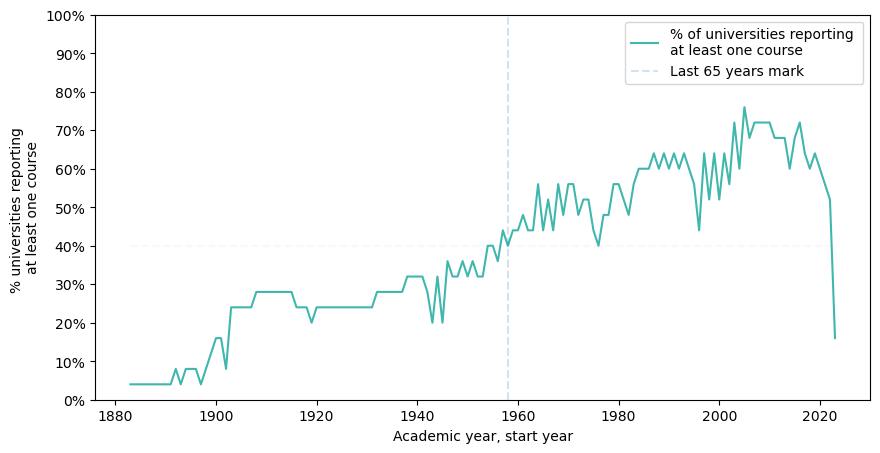

In [21]:
fig, axes_orig = plt.subplots(figsize=(8, 5), nrows=1, ncols=1)
axes = axes_orig

(df.groupby("start_yr")["ipeds_id"].nunique() / df["ipeds_id"].nunique() * 100).plot(
    color=sns.color_palette("mako_r")[1],
    figsize=(10, 5),
    ax=axes,
    label="% of universities reporting \nat least one course",
)
axes.set_xlabel("Academic year, start year")
axes.set_ylabel("% universities reporting \nat least one course")
axes.set_ylim(0, 1)
axes.vlines(
    1958, ymin=0, ymax=100, linestyles="--", alpha=0.2, label="Last 65 years mark"
)
axes.legend()
axes.hlines(
    40, xmax=max_start_yr, xmin=min_start_yr, linestyles="--", alpha=0.05, colors="grey"
)
# axes.set_frame_on(False)
axes.set_yticks(range(0, 110, 10))
axes.set_yticklabels([f"{i}%" for i in range(0, 110, 10)])